In [35]:
import joblib
import shap
import lime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

pd.set_option("display.max_columns", None)

In [66]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load("../ml/best_model.pkl")

preprocessor = joblib.load("../ml/preprocessor.pkl")

X_test = joblib.load("../data/processed/X_test.pkl")

y_test = joblib.load("../data/processed/y_test.pkl")

In [70]:
X_sample = X_test[:1000]

In [71]:
feature_names = preprocessor.get_feature_names_out()

X_sample_df = pd.DataFrame(
    X_sample,
    columns=feature_names
)

print(X_sample_df.shape)

(1000, 225)


In [72]:
X_sample_df.head()

,num__SK_ID_CURR,num__CNT_CHILDREN,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__AMT_ANNUITY,num__AMT_GOODS_PRICE,num__REGION_POPULATION_RELATIVE,num__DAYS_BIRTH,num__DAYS_EMPLOYED,num__DAYS_REGISTRATION,num__DAYS_ID_PUBLISH,num__FLAG_MOBIL,num__FLAG_EMP_PHONE,num__FLAG_WORK_PHONE,num__FLAG_CONT_MOBILE,num__FLAG_PHONE,num__FLAG_EMAIL,num__CNT_FAM_MEMBERS,num__REGION_RATING_CLIENT,num__REGION_RATING_CLIENT_W_CITY,num__HOUR_APPR_PROCESS_START,num__REG_REGION_NOT_LIVE_REGION,num__REG_REGION_NOT_WORK_REGION,num__LIVE_REGION_NOT_WORK_REGION,num__REG_CITY_NOT_LIVE_CITY,num__REG_CITY_NOT_WORK_CITY,num__LIVE_CITY_NOT_WORK_CITY,num__EXT_SOURCE_1,num__EXT_SOURCE_2,num__EXT_SOURCE_3,num__APARTMENTS_AVG,num__BASEMENTAREA_AVG,num__YEARS_BEGINEXPLUATATION_AVG,num__ELEVATORS_AVG,num__ENTRANCES_AVG,num__FLOORSMAX_AVG,num__LANDAREA_AVG,num__LIVINGAREA_AVG,num__NONLIVINGAREA_AVG,num__APARTMENTS_MODE,num__BASEMENTAREA_MODE,num__YEARS_BEGINEXPLUATATION_MODE,num__ELEVATORS_MODE,num__ENTRANCES_MODE,num__FLOORSMAX_MODE,num__LANDAREA_MODE,num__LIVINGAREA_MODE,num__NONLIVINGAREA_MODE,num__APARTMENTS_MEDI,num__BASEMENTAREA_MEDI,num__YEARS_BEGINEXPLUATATION_MEDI,num__ELEVATORS_MEDI,num__ENTRANCES_MEDI,num__FLOORSMAX_MEDI,num__LANDAREA_MEDI,num__LIVINGAREA_MEDI,num__NONLIVINGAREA_MEDI,num__TOTALAREA_MODE,num__OBS_30_CNT_SOCIAL_CIRCLE,num__DEF_30_CNT_SOCIAL_CIRCLE,num__OBS_60_CNT_SOCIAL_CIRCLE,num__DEF_60_CNT_SOCIAL_CIRCLE,num__DAYS_LAST_PHONE_CHANGE,num__FLAG_DOCUMENT_2,num__FLAG_DOCUMENT_3,num__FLAG_DOCUMENT_4,num__FLAG_DOCUMENT_5,num__FLAG_DOCUMENT_6,num__FLAG_DOCUMENT_7,num__FLAG_DOCUMENT_8,num__FLAG_DOCUMENT_9,num__FLAG_DOCUMENT_10,num__FLAG_DOCUMENT_11,num__FLAG_DOCUMENT_12,num__FLAG_DOCUMENT_13,num__FLAG_DOCUMENT_14,num__FLAG_DOCUMENT_15,num__FLAG_DOCUMENT_16,num__FLAG_DOCUMENT_17,num__FLAG_DOCUMENT_18,num__FLAG_DOCUMENT_19,num__FLAG_DOCUMENT_20,num__FLAG_DOCUMENT_21,num__AMT_REQ_CREDIT_BUREAU_HOUR,num__AMT_REQ_CREDIT_BUREAU_DAY,num__AMT_REQ_CREDIT_BUREAU_WEEK,num__AMT_REQ_CREDIT_BUREAU_MON,num__AMT_REQ_CREDIT_BUREAU_QRT,num__AMT_REQ_CREDIT_BUREAU_YEAR,cat__NAME_CONTRACT_TYPE_Cash loans,cat__NAME_CONTRACT_TYPE_Revolving loans,cat__CODE_GENDER_F,cat__CODE_GENDER_M,cat__CODE_GENDER_XNA,cat__FLAG_OWN_CAR_N,cat__FLAG_OWN_CAR_Y,cat__FLAG_OWN_REALTY_N,cat__FLAG_OWN_REALTY_Y,cat__NAME_TYPE_SUITE_Children,cat__NAME_TYPE_SUITE_Family,cat__NAME_TYPE_SUITE_Group of people,cat__NAME_TYPE_SUITE_Other_A,cat__NAME_TYPE_SUITE_Other_B,"cat__NAME_TYPE_SUITE_Spouse, partner",cat__NAME_TYPE_SUITE_Unaccompanied,cat__NAME_INCOME_TYPE_Businessman,cat__NAME_INCOME_TYPE_Commercial associate,cat__NAME_INCOME_TYPE_Maternity leave,cat__NAME_INCOME_TYPE_Pensioner,cat__NAME_INCOME_TYPE_State servant,cat__NAME_INCOME_TYPE_Student,cat__NAME_INCOME_TYPE_Unemployed,cat__NAME_INCOME_TYPE_Working,cat__NAME_EDUCATION_TYPE_Academic degree,cat__NAME_EDUCATION_TYPE_Higher education,cat__NAME_EDUCATION_TYPE_Incomplete higher,cat__NAME_EDUCATION_TYPE_Lower secondary,cat__NAME_EDUCATION_TYPE_Secondary / secondary special,cat__NAME_FAMILY_STATUS_Civil marriage,cat__NAME_FAMILY_STATUS_Married,cat__NAME_FAMILY_STATUS_Separated,cat__NAME_FAMILY_STATUS_Single / not married,cat__NAME_FAMILY_STATUS_Unknown,cat__NAME_FAMILY_STATUS_Widow,cat__NAME_HOUSING_TYPE_Co-op apartment,cat__NAME_HOUSING_TYPE_House / apartment,cat__NAME_HOUSING_TYPE_Municipal apartment,cat__NAME_HOUSING_TYPE_Office apartment,cat__NAME_HOUSING_TYPE_Rented apartment,cat__NAME_HOUSING_TYPE_With parents,cat__OCCUPATION_TYPE_Accountants,cat__OCCUPATION_TYPE_Cleaning staff,cat__OCCUPATION_TYPE_Cooking staff,cat__OCCUPATION_TYPE_Core staff,cat__OCCUPATION_TYPE_Drivers,cat__OCCUPATION_TYPE_HR staff,cat__OCCUPATION_TYPE_High skill tech staff,cat__OCCUPATION_TYPE_IT staff,cat__OCCUPATION_TYPE_Laborers,cat__OCCUPATION_TYPE_Low-skill Laborers,cat__OCCUPATION_TYPE_Managers,cat__OCCUPATION_TYPE_Medicine staff,cat__OCCUPATION_TYPE_Private service staff,cat__OCCUPATION_TYPE_Realty agents,cat__OCCUPATION_TYPE_Sales staff,cat__OCCUPATION_TYPE_Secr

In [73]:
import shap
explainer = shap.TreeExplainer(model)

In [74]:
shap_values = explainer.shap_values(X_sample_df)

d:\Creditwise-Ai\creditwise_ai\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [75]:
type(shap_values)

numpy.ndarray

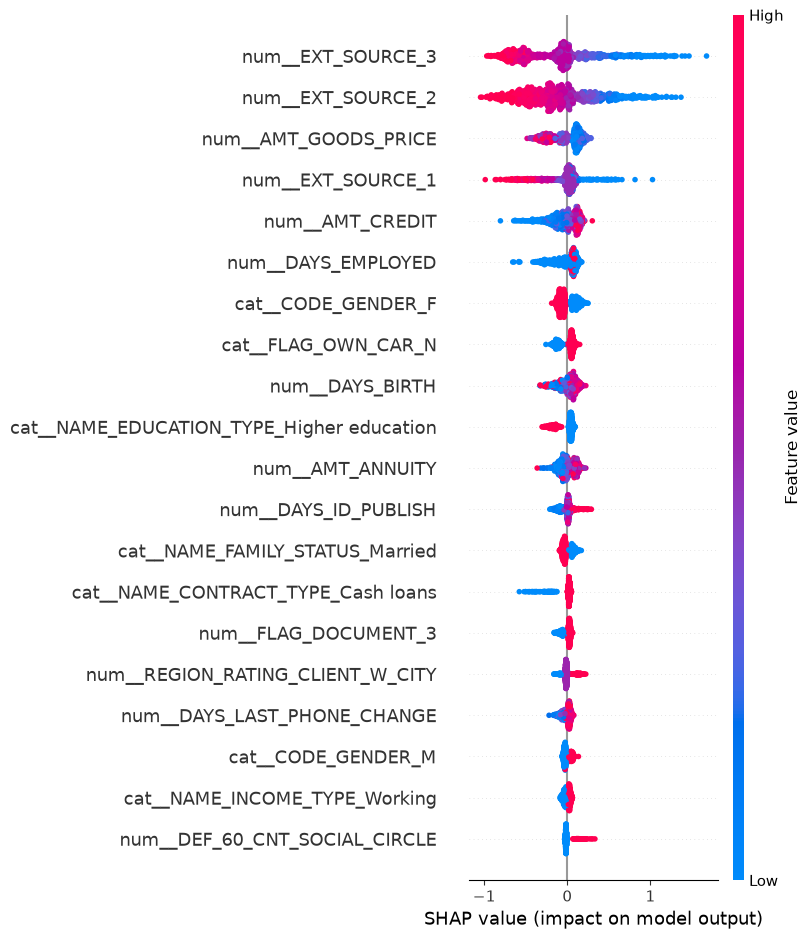

In [76]:
shap.summary_plot(
    shap_values,
    X_sample_df
)

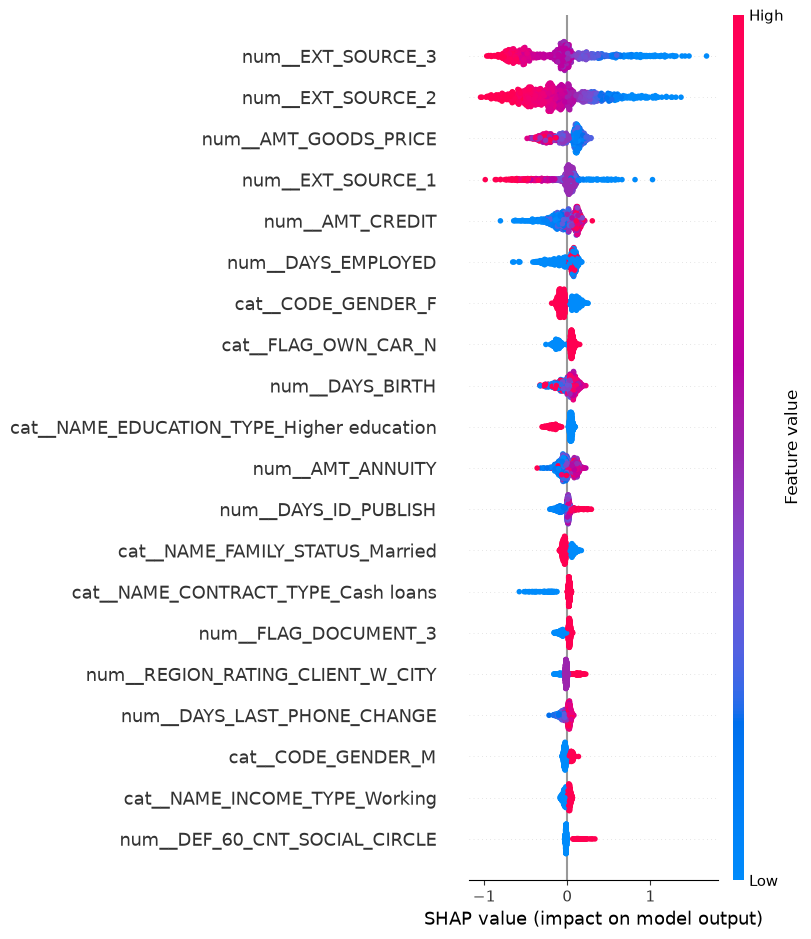

In [77]:
shap.summary_plot(
    shap_values,
    X_sample_df,
    show=False
)

plt.savefig(
    "../reports/explainability/shap_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [78]:
customer_index = 10

In [79]:
explanation = shap.Explanation(
    values=shap_values[customer_index],
    base_values=explainer.expected_value,
    data=X_sample_df.iloc[customer_index],
    feature_names=feature_names
)

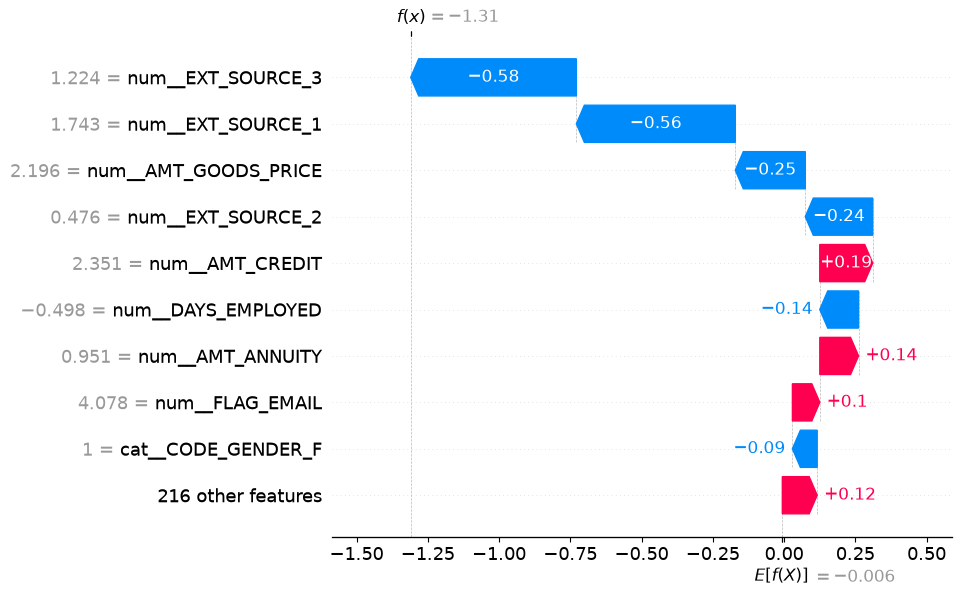

In [80]:
shap.plots.waterfall(explanation)

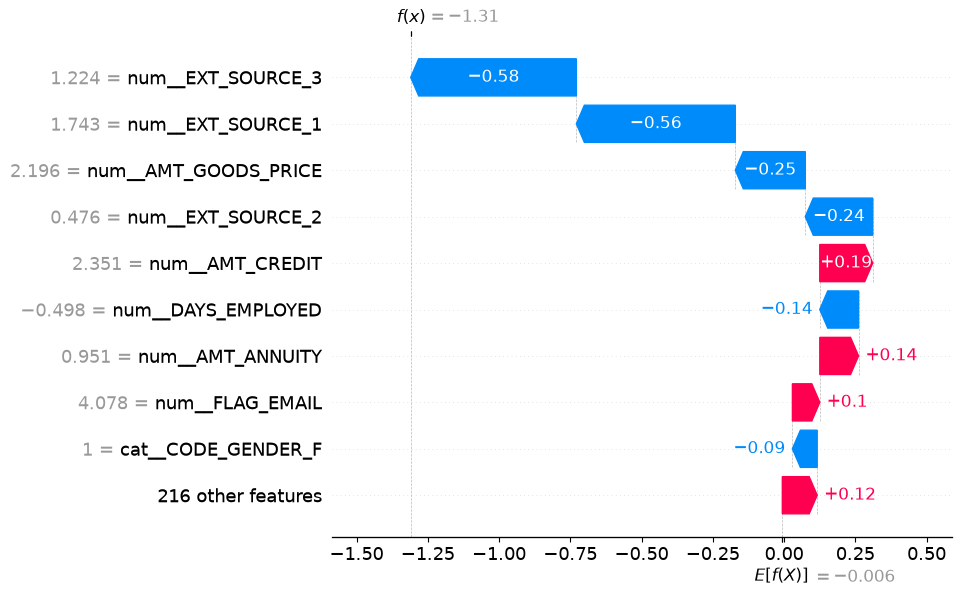

In [81]:
shap.plots.waterfall(
    explanation,
    show=False
)

plt.savefig(
    "../reports/explainability/shap_waterfall.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [82]:
from lime.lime_tabular import LimeTabularExplainer

In [83]:
lime_explainer = LimeTabularExplainer(
    training_data=X_sample_df.values,
    feature_names=feature_names,
    class_names=["Non-Default", "Default"],
    mode="classification"
)

In [84]:
customer_index = 10

lime_exp = lime_explainer.explain_instance(
    X_sample_df.iloc[customer_index].values,
    model.predict_proba,
    num_features=10
)

d:\Creditwise-Ai\creditwise_ai\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [85]:
lime_exp.as_list()

[('num__EXT_SOURCE_3 > 0.72', -0.12937009491878412),
 ('cat__ORGANIZATION_TYPE_Insurance <= 0.00', -0.12289397946822632),
 ('cat__ORGANIZATION_TYPE_Religion <= 0.00', 0.11219172100247897),
 ('num__FLAG_DOCUMENT_17 <= -0.02', -0.09741892998743411),
 ('num__EXT_SOURCE_1 > 0.01', -0.08251410103286556),
 ('cat__OCCUPATION_TYPE_Realty agents <= 0.00', -0.07927526796747204),
 ('cat__NAME_EDUCATION_TYPE_Academic degree <= 0.00', 0.0785131331392811),
 ('num__FLAG_DOCUMENT_13 <= -0.06', 0.0782084336417687),
 ('0.00 < cat__NAME_FAMILY_STATUS_Married <= 1.00', -0.07280901360239136),
 ('cat__ORGANIZATION_TYPE_Trade: type 6 <= 0.00', -0.06733242638473932)]

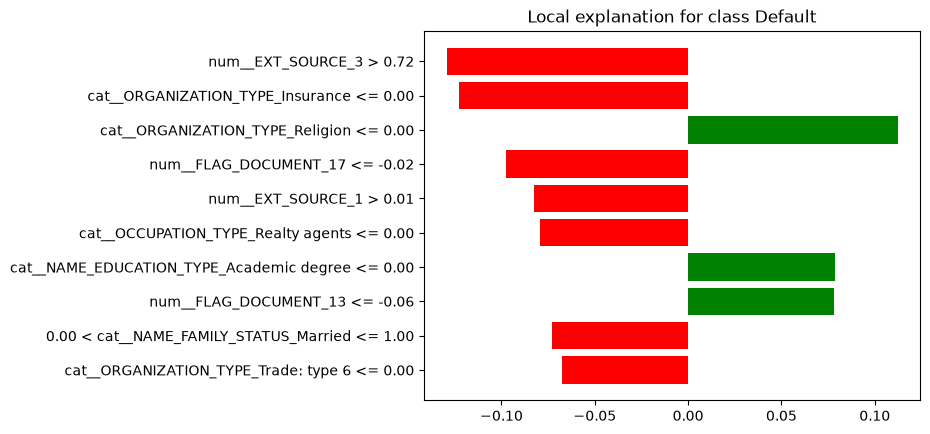

In [86]:
fig = lime_exp.as_pyplot_figure()

fig.savefig(
    "../reports/explainability/lime_explanation.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [87]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [88]:
from backend.recommendation_engine import (
    generate_recommendations
)

In [89]:
customer = {
    "debt_to_income_ratio": 0.55,
    "loan_burden_ratio": 0.35,
    "credit_inquiry_ratio": 0.12,
    "employment_years": 1.5,
    "ext_score_mean": 0.40
}

In [90]:
recommendations = generate_recommendations(customer)

for rec in recommendations:
    print("•", rec)

• Reduce existing debt to improve approval chances.
• Lower monthly repayment obligations.
• Avoid multiple credit applications.
• Maintain stable employment history.
• Improve your credit profile through timely repayments.


In [91]:
top_features = pd.Series(
    shap_values[customer_index],
    index=feature_names
).sort_values(ascending=False)

top_features.head(10)

num__AMT_CREDIT                              0.185820
num__AMT_ANNUITY                             0.135893
num__FLAG_EMAIL                              0.096149
cat__FLAG_OWN_CAR_N                          0.070614
num__DAYS_BIRTH                              0.053104
cat__NAME_EDUCATION_TYPE_Higher education    0.051712
num__OBS_60_CNT_SOCIAL_CIRCLE                0.038977
cat__NAME_CONTRACT_TYPE_Cash loans           0.020571
num__AMT_REQ_CREDIT_BUREAU_QRT               0.019805
num__REGION_POPULATION_RELATIVE              0.016106
dtype: float64

In [92]:
recommendations = []

for feature, value in top_features.head(10).items():

    if "debt_to_income_ratio" in feature and value > 0:
        recommendations.append(
            "Reduce total debt relative to your income."
        )

    elif "loan_burden_ratio" in feature and value > 0:
        recommendations.append(
            "Lower monthly repayment obligations."
        )

    elif "credit_inquiry_ratio" in feature and value > 0:
        recommendations.append(
            "Avoid applying for multiple credit products."
        )

    elif "employment_years" in feature and value < 0:
        recommendations.append(
            "Continue maintaining stable employment."
        )

    elif "ext_score_mean" in feature and value > 0:
        recommendations.append(
            "Improve your external credit score."
        )

print(set(recommendations))

set()


In [93]:
friendly_explanation = []

for feature, value in top_features.head(5).items():

    if value > 0:

        if "debt_to_income_ratio" in feature:
            friendly_explanation.append(
                "Your debt level is high relative to your income."
            )

        elif "credit_inquiry_ratio" in feature:
            friendly_explanation.append(
                "You recently made multiple credit inquiries."
            )

        elif "employment_years" in feature:
            friendly_explanation.append(
                "Your employment history is relatively short."
            )

        elif "ext_score_mean" in feature:
            friendly_explanation.append(
                "Your external credit score is lower than average."
            )

print("Your risk score increased because:\n")

for item in friendly_explanation:
    print("•", item)

Your risk score increased because:



In [62]:
print(top_features.head(20))

num__AMT_CREDIT                                           0.185820
num__AMT_ANNUITY                                          0.135893
num__FLAG_EMAIL                                           0.096149
cat__FLAG_OWN_CAR_N                                       0.070614
num__DAYS_BIRTH                                           0.053104
cat__NAME_EDUCATION_TYPE_Higher education                 0.051712
num__OBS_60_CNT_SOCIAL_CIRCLE                             0.038977
cat__NAME_CONTRACT_TYPE_Cash loans                        0.020571
num__AMT_REQ_CREDIT_BUREAU_QRT                            0.019805
num__REGION_POPULATION_RELATIVE                           0.016106
num__YEARS_BEGINEXPLUATATION_MEDI                         0.014092
cat__NAME_EDUCATION_TYPE_Secondary / secondary special    0.012558
num__HOUR_APPR_PROCESS_START                              0.010121
num__FLAG_DOCUMENT_3                                      0.009857
cat__ORGANIZATION_TYPE_Business Entity Type 3             0.00

In [94]:
for feature in feature_names:
    if any(x in feature for x in [
        "debt",
        "burden",
        "inquiry",
        "employment",
        "ext_score"
    ]):
        print(feature)

In [96]:
import joblib
import pandas as pd

model = joblib.load("../ml/best_model.pkl")

preprocessor = joblib.load("../ml/preprocessor.pkl")

X_train = joblib.load("../data/processed/X_train.pkl")

X_test = joblib.load("../data/processed/X_test.pkl")

y_test = joblib.load("../data/processed/y_test.pkl")

In [97]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

225


In [98]:
X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

In [99]:
print(X_train_df.shape)
print(X_test_df.shape)

(452296, 225)
(61503, 225)


In [100]:
for feature in feature_names:
    if any(keyword in feature.lower() for keyword in [
        "debt",
        "burden",
        "inquiry",
        "employment",
        "ext_score"
    ]):
        print(feature)

In [101]:
import shap

explainer = shap.TreeExplainer(model)

X_sample = X_test_df.sample(
    n=1000,
    random_state=42
)

shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

d:\Creditwise-Ai\creditwise_ai\venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [102]:
customer_index = 10
top_features = pd.Series(
    shap_values[customer_index],
    index=feature_names
).sort_values(ascending=False)

print(top_features.head(20))

cat__CODE_GENDER_F                                        0.195225
num__REGION_RATING_CLIENT_W_CITY                          0.117797
num__AMT_GOODS_PRICE                                      0.107563
cat__FLAG_OWN_CAR_N                                       0.075617
cat__NAME_EDUCATION_TYPE_Higher education                 0.046675
cat__CODE_GENDER_M                                        0.038872
num__DAYS_EMPLOYED                                        0.030868
num__FLAG_DOCUMENT_3                                      0.030299
num__EXT_SOURCE_1                                         0.021857
num__AMT_REQ_CREDIT_BUREAU_YEAR                           0.020356
cat__NAME_CONTRACT_TYPE_Cash loans                        0.016557
num__AMT_REQ_CREDIT_BUREAU_QRT                            0.009836
cat__NAME_EDUCATION_TYPE_Secondary / secondary special    0.009335
num__OBS_60_CNT_SOCIAL_CIRCLE                             0.008361
cat__OCCUPATION_TYPE_Core staff                           0.00

In [103]:
recommendations = []

for feature, value in top_features.head(20).items():

    if "EXT_SOURCE" in feature and value > 0:
        recommendations.append(
            "Improve your credit history by maintaining timely payments."
        )

    elif "AMT_ANNUITY" in feature and value > 0:
        recommendations.append(
            "Reduce monthly repayment obligations."
        )

    elif "AMT_CREDIT" in feature and value > 0:
        recommendations.append(
            "Consider applying for a smaller loan amount."
        )

    elif "AMT_INCOME_TOTAL" in feature and value < 0:
        recommendations.append(
            "Increasing income may improve your approval chances."
        )

    elif "DAYS_EMPLOYED" in feature and value > 0:
        recommendations.append(
            "Maintain stable employment to strengthen your application."
        )

In [104]:
for recommendation in set(recommendations):
    print("•", recommendation)

• Improve your credit history by maintaining timely payments.
• Maintain stable employment to strengthen your application.


In [105]:
print(top_features.head(20))

cat__CODE_GENDER_F                                        0.195225
num__REGION_RATING_CLIENT_W_CITY                          0.117797
num__AMT_GOODS_PRICE                                      0.107563
cat__FLAG_OWN_CAR_N                                       0.075617
cat__NAME_EDUCATION_TYPE_Higher education                 0.046675
cat__CODE_GENDER_M                                        0.038872
num__DAYS_EMPLOYED                                        0.030868
num__FLAG_DOCUMENT_3                                      0.030299
num__EXT_SOURCE_1                                         0.021857
num__AMT_REQ_CREDIT_BUREAU_YEAR                           0.020356
cat__NAME_CONTRACT_TYPE_Cash loans                        0.016557
num__AMT_REQ_CREDIT_BUREAU_QRT                            0.009836
cat__NAME_EDUCATION_TYPE_Secondary / secondary special    0.009335
num__OBS_60_CNT_SOCIAL_CIRCLE                             0.008361
cat__OCCUPATION_TYPE_Core staff                           0.00

In [107]:
top_features = pd.Series(
    shap_values[customer_index],
    index=feature_names
).sort_values(ascending=False)

top_features.head(10)

cat__CODE_GENDER_F                           0.195225
num__REGION_RATING_CLIENT_W_CITY             0.117797
num__AMT_GOODS_PRICE                         0.107563
cat__FLAG_OWN_CAR_N                          0.075617
cat__NAME_EDUCATION_TYPE_Higher education    0.046675
cat__CODE_GENDER_M                           0.038872
num__DAYS_EMPLOYED                           0.030868
num__FLAG_DOCUMENT_3                         0.030299
num__EXT_SOURCE_1                            0.021857
num__AMT_REQ_CREDIT_BUREAU_YEAR              0.020356
dtype: float64

In [108]:
recommendations = []

for feature, value in top_features.head(10).items():

    if "debt_to_income_ratio" in feature and value > 0:
        recommendations.append(
            "Reduce total debt relative to your income."
        )

    elif "loan_burden_ratio" in feature and value > 0:
        recommendations.append(
            "Lower monthly repayment obligations."
        )

    elif "credit_inquiry_ratio" in feature and value > 0:
        recommendations.append(
            "Avoid applying for multiple credit products."
        )

    elif "employment_years" in feature and value < 0:
        recommendations.append(
            "Continue maintaining stable employment."
        )

    elif "ext_score_mean" in feature and value > 0:
        recommendations.append(
            "Improve your external credit score."
        )

print(set(recommendations))

set()


In [110]:
friendly_explanation = []

for feature, value in top_features.head(10).items():

    if value <= 0:
        continue

    if "EXT_SOURCE_1" in feature:
        friendly_explanation.append(
            "Your external credit score indicates elevated risk."
        )

    elif "AMT_REQ_CREDIT_BUREAU_YEAR" in feature:
        friendly_explanation.append(
            "You have made several recent credit inquiries."
        )

    elif "DAYS_EMPLOYED" in feature:
        friendly_explanation.append(
            "Your employment history may increase your risk profile."
        )

    elif "AMT_GOODS_PRICE" in feature:
        friendly_explanation.append(
            "The requested purchase amount is relatively high."
        )

    elif "REGION_RATING_CLIENT_W_CITY" in feature:
        friendly_explanation.append(
            "Your geographic region is associated with higher historical risk."
        )

    elif "FLAG_OWN_CAR_N" in feature:
        friendly_explanation.append(
            "Limited asset ownership may contribute to higher risk."
        )

    elif "NAME_EDUCATION_TYPE_Higher education" in feature:
        friendly_explanation.append(
            "Education level influenced the model's assessment."
        )

In [111]:
print("Your risk score increased because:\n")

for item in set(friendly_explanation):
    print("•", item)

Your risk score increased because:

• The requested purchase amount is relatively high.
• Your geographic region is associated with higher historical risk.
• Limited asset ownership may contribute to higher risk.
• Your employment history may increase your risk profile.
• Education level influenced the model's assessment.
• You have made several recent credit inquiries.
• Your external credit score indicates elevated risk.


In [112]:
recommendations = []

for feature, value in top_features.head(10).items():

    if value <= 0:
        continue

    if "EXT_SOURCE_1" in feature:
        recommendations.append(
            "Improve your credit history by making payments on time."
        )

    elif "AMT_REQ_CREDIT_BUREAU_YEAR" in feature:
        recommendations.append(
            "Avoid applying for multiple credit products within a short period."
        )

    elif "DAYS_EMPLOYED" in feature:
        recommendations.append(
            "Maintaining stable employment can strengthen future applications."
        )

    elif "AMT_GOODS_PRICE" in feature:
        recommendations.append(
            "Consider reducing the requested loan amount."
        )

    elif "FLAG_OWN_CAR_N" in feature:
        recommendations.append(
            "Providing additional financial documentation may improve your profile."
        )

In [113]:
print("Recommendations:\n")

for item in set(recommendations):
    print("✓", item)

Recommendations:

✓ Maintaining stable employment can strengthen future applications.
✓ Providing additional financial documentation may improve your profile.
✓ Consider reducing the requested loan amount.
✓ Avoid applying for multiple credit products within a short period.
✓ Improve your credit history by making payments on time.


Approval Probability: 72%

Main Risk Factors:

▼ High debt-to-income ratio

▼ Multiple recent inquiries

▲ Stable employment history

Recommendations:

✓ Reduce debt below 30% of income

✓ Avoid new credit applications